In [1]:
import json
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# just setting up some basic plot styling
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Libraries loaded ok")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded ok


In [6]:
import csv

expected = {}
expected_file = r'C:\SAST-Benchmark\BenchmarkJava\expectedresults-1.2.csv'

with open(expected_file, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_name = row['# test name']
        expected[test_name] = {
            'category': row[' category'].strip(),
            'real_vulnerability': row[' real vulnerability'].strip() == 'true',
            'cwe': row[' cwe'].strip()
        }

print(f"Loaded {len(expected)} test cases from ground truth")
print("Sample:", list(expected.items())[0])

Loaded 2740 test cases from ground truth
Sample: ('BenchmarkTest00001', {'category': 'pathtraver', 'real_vulnerability': True, 'cwe': '22'})


In [7]:
# parse the spotbugs xml output and extract findings
# each finding has a class name which maps to a benchmark test case

tree = ET.parse(r'C:\SAST-Benchmark\results\Benchmark_1.2-SpotBugs.xml')
root = tree.getroot()

spotbugs_findings = []

for bug in root.findall('.//BugInstance'):
    source = bug.find('SourceLine')
    classname = bug.find('Class')
    if classname is not None:
        cname = classname.get('classname', '')
        # extract just the test name e.g. BenchmarkTest00001
        if 'BenchmarkTest' in cname:
            test_name = cname.split('.')[-1].split('$')[0]
            bug_type = bug.get('type', '')
            category = bug.get('category', '')
            spotbugs_findings.append({
                'test_name': test_name,
                'bug_type': bug_type,
                'category': category
            })

print(f"SpotBugs total findings: {len(spotbugs_findings)}")
print("Sample:", spotbugs_findings[0])

SpotBugs total findings: 14454
Sample: {'test_name': 'BenchmarkTest00001', 'bug_type': 'COOKIE_USAGE', 'category': 'SECURITY'}


In [8]:
# parse pmd xml output - similar approach to spotbugs
tree_pmd = ET.parse(r'C:\SAST-Benchmark\results\Benchmark_1.2-PMD.xml')
root_pmd = tree_pmd.getroot()

pmd_findings = []

for file in root_pmd.findall('.//{http://pmd.sourceforge.net/report/2.0.0}file'):
    filename = file.get('name', '')
    if 'BenchmarkTest' in filename:
        # pull test name from the filename
        test_name = filename.split('\\')[-1].replace('.java', '')
        for violation in file.findall('{http://pmd.sourceforge.net/report/2.0.0}violation'):
            rule = violation.get('rule', '')
            ruleset = violation.get('ruleset', '')
            pmd_findings.append({
                'test_name': test_name,
                'rule': rule,
                'ruleset': ruleset
            })

print(f"PMD total findings: {len(pmd_findings)}")
if pmd_findings:
    print("Sample:", pmd_findings[0])
else:
    print("No findings - checking xml structure...")
    print(root_pmd.tag)
    print([child.tag for child in root_pmd])

PMD total findings: 12397
Sample: {'test_name': 'BenchmarkTest00001', 'rule': 'UnnecessaryAnnotationValueElement', 'ruleset': 'Code Style'}


In [10]:
# parse semgrep sarif output
# sarif is json format so easier to work with

with open(r'C:\SAST-Benchmark\results\Benchmark_1.2-Semgrep.sarif', encoding='utf-8') as f:
    sarif_data = json.load(f)

semgrep_findings = []

for run in sarif_data.get('runs', []):
    for result in run.get('results', []):
        rule_id = result.get('ruleId', '')
        locations = result.get('locations', [])
        for loc in locations:
            uri = loc.get('physicalLocation', {}).get('artifactLocation', {}).get('uri', '')
            if 'BenchmarkTest' in uri:
                # extract just the test name from the full path
                test_name = uri.split('/')[-1].split('\\')[-1].replace('.java', '')
                semgrep_findings.append({
                    'test_name': test_name,
                    'rule_id': rule_id
                })

print(f"Semgrep total findings: {len(semgrep_findings)}")
if semgrep_findings:
    print("Sample:", semgrep_findings[0])

Semgrep total findings: 1909
Sample: {'test_name': 'BenchmarkTest00001', 'rule_id': 'java.lang.security.httpservlet-path-traversal.httpservlet-path-traversal'}


In [11]:
# load sonarqube findings from the json we downloaded via api

with open(r'C:\SAST-Benchmark\results\sonar_issues_all.json', encoding='utf-8') as f:
    sonar_data = json.load(f)

sonar_findings = []

for issue in sonar_data.get('issues', []):
    component = issue.get('component', '')
    if 'BenchmarkTest' in component:
        # extract test name from component key
        test_name = component.split('/')[-1].replace('.java', '')
        rule = issue.get('rule', '')
        severity = issue.get('severity', '')
        sonar_findings.append({
            'test_name': test_name,
            'rule': rule,
            'severity': severity
        })

print(f"SonarQube total findings: {len(sonar_findings)}")
if sonar_findings:
    print("Sample:", sonar_findings[0])

SonarQube total findings: 9983
Sample: {'test_name': 'BenchmarkTest00025', 'rule': 'java:S1989', 'severity': 'MINOR'}


In [12]:
# now the main analysis - compare each tool's findings against ground truth
# for each test case, a tool either flagged it or didn't
# we then check if that was correct or not

def compute_metrics(findings, expected, tool_name):
    # get set of test cases this tool flagged
    flagged = set(f['test_name'] for f in findings)
    
    tp = 0  # flagged and actually vulnerable
    fp = 0  # flagged but not vulnerable
    fn = 0  # not flagged but actually vulnerable
    tn = 0  # not flagged and not vulnerable
    
    for test_name, info in expected.items():
        is_vulnerable = info['real_vulnerability']
        was_flagged = test_name in flagged
        
        if is_vulnerable and was_flagged:
            tp += 1
        elif not is_vulnerable and was_flagged:
            fp += 1
        elif is_vulnerable and not was_flagged:
            fn += 1
        else:
            tn += 1
    
    # calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # false positive rate
    
    return {
        'tool': tool_name,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1': round(f1, 3),
        'FP_Rate': round(fpr, 3)
    }

# run for all four tools
results = []
results.append(compute_metrics(spotbugs_findings, expected, 'SpotBugs+FSB'))
results.append(compute_metrics(pmd_findings, expected, 'PMD'))
results.append(compute_metrics(semgrep_findings, expected, 'Semgrep'))
results.append(compute_metrics(sonar_findings, expected, 'SonarQube'))

# put into a dataframe so its easy to look at
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

        tool   TP   FP  FN  TN  Precision  Recall    F1  FP_Rate
SpotBugs+FSB 1415 1266   0  59      0.528   1.000 0.691    0.955
         PMD 1415 1325   0   0      0.516   1.000 0.681    1.000
     Semgrep  995  520 420 805      0.657   0.703 0.679    0.392
   SonarQube 1353 1254  62  71      0.519   0.956 0.673    0.946


In [13]:
# clean summary table for the report
summary = df_results[['tool', 'Precision', 'Recall', 'F1', 'FP_Rate']].copy()
summary.columns = ['Tool', 'Precision', 'Recall', 'F1 Score', 'FP Rate']
summary['FP Rate %'] = (summary['FP Rate'] * 100).round(1)
summary['Precision %'] = (summary['Precision'] * 100).round(1)
summary['Recall %'] = (summary['Recall'] * 100).round(1)
summary['F1 Score %'] = (summary['F1 Score'] * 100).round(1)

print("=" * 65)
print(f"{'Tool':<15} {'Precision%':>10} {'Recall%':>10} {'F1%':>10} {'FP Rate%':>10}")
print("=" * 65)
for _, row in summary.iterrows():
    print(f"{row['Tool']:<15} {row['Precision %']:>10} {row['Recall %']:>10} {row['F1 Score %']:>10} {row['FP Rate %']:>10}")
print("=" * 65)

Tool            Precision%    Recall%        F1%   FP Rate%
SpotBugs+FSB          52.8      100.0       69.1       95.5
PMD                   51.6      100.0       68.1      100.0
Semgrep               65.7       70.3       67.9       39.2
SonarQube             51.9       95.6       67.3       94.6


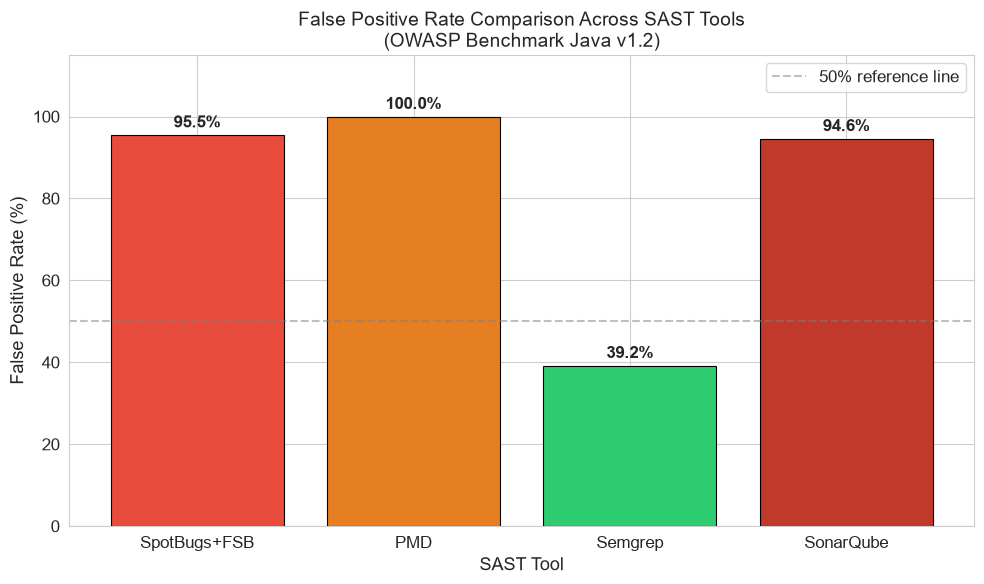

Chart saved


In [14]:
# bar chart comparing FP rates across all four tools
fig, ax = plt.subplots(figsize=(10, 6))

tools = df_results['tool']
fp_rates = df_results['FP_Rate'] * 100

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#e74c3c']
bars = ax.bar(tools, fp_rates, color=['#e74c3c', '#e67e22', '#2ecc71', '#c0392b'], 
              edgecolor='black', linewidth=0.8)

# add value labels on top of bars
for bar, val in zip(bars, fp_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('SAST Tool', fontsize=13)
ax.set_ylabel('False Positive Rate (%)', fontsize=13)
ax.set_title('False Positive Rate Comparison Across SAST Tools\n(OWASP Benchmark Java v1.2)', fontsize=14)
ax.set_ylim(0, 115)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% reference line')
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\SAST-Benchmark\results\chart_fp_rates.png', dpi=150)
plt.show()
print("Chart saved")

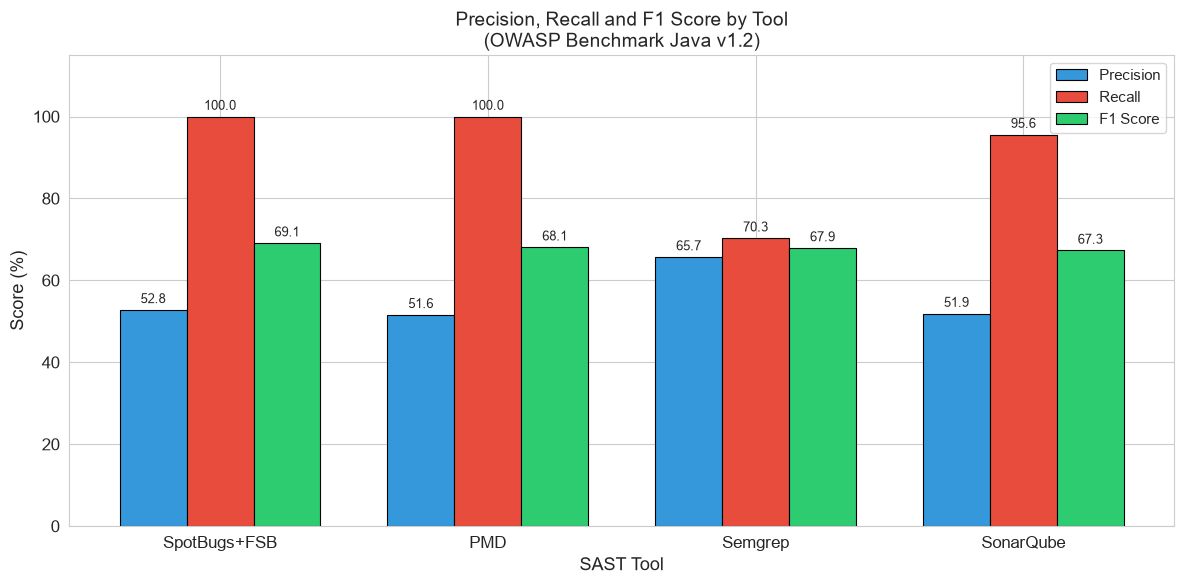

Chart saved


In [15]:
# grouped bar chart showing precision, recall and f1 side by side for each tool
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(df_results))
width = 0.25

bars1 = ax.bar([i - width for i in x], df_results['Precision'] * 100, 
               width, label='Precision', color='#3498db', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x, df_results['Recall'] * 100, 
               width, label='Recall', color='#e74c3c', edgecolor='black', linewidth=0.8)
bars3 = ax.bar([i + width for i in x], df_results['F1'] * 100, 
               width, label='F1 Score', color='#2ecc71', edgecolor='black', linewidth=0.8)

ax.set_xlabel('SAST Tool', fontsize=13)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Precision, Recall and F1 Score by Tool\n(OWASP Benchmark Java v1.2)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_results['tool'])
ax.set_ylim(0, 115)
ax.legend(fontsize=11)

# add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(r'C:\SAST-Benchmark\results\chart_precision_recall_f1.png', dpi=150)
plt.show()
print("Chart saved")

In [16]:
# now the more interesting part - breaking down FP rates by CWE category
# this is what makes our study different from Xiong & Zhang (2026)

# first lets see what categories are in the benchmark
categories = {}
for test_name, info in expected.items():
    cat = info['category']
    if cat not in categories:
        categories[cat] = {'total': 0, 'vulnerable': 0}
    categories[cat]['total'] += 1
    if info['real_vulnerability']:
        categories[cat]['vulnerable'] += 1

print("Categories in benchmark:")
for cat, counts in sorted(categories.items()):
    print(f"  {cat}: {counts['total']} test cases, {counts['vulnerable']} vulnerable")

Categories in benchmark:
  cmdi: 251 test cases, 126 vulnerable
  crypto: 246 test cases, 130 vulnerable
  hash: 236 test cases, 129 vulnerable
  ldapi: 59 test cases, 27 vulnerable
  pathtraver: 268 test cases, 133 vulnerable
  securecookie: 67 test cases, 36 vulnerable
  sqli: 504 test cases, 272 vulnerable
  trustbound: 126 test cases, 83 vulnerable
  weakrand: 493 test cases, 218 vulnerable
  xpathi: 35 test cases, 15 vulnerable
  xss: 455 test cases, 246 vulnerable


In [17]:
# compute FP rate per category for each tool
# this is the key original contribution of this project

def fp_rate_by_category(findings, expected, tool_name):
    flagged = set(f['test_name'] for f in findings)
    
    cat_stats = {}
    for test_name, info in expected.items():
        cat = info['category']
        if cat not in cat_stats:
            cat_stats[cat] = {'fp': 0, 'tn': 0, 'tp': 0, 'fn': 0}
        
        is_vuln = info['real_vulnerability']
        was_flagged = test_name in flagged
        
        if is_vuln and was_flagged:
            cat_stats[cat]['tp'] += 1
        elif not is_vuln and was_flagged:
            cat_stats[cat]['fp'] += 1
        elif is_vuln and not was_flagged:
            cat_stats[cat]['fn'] += 1
        else:
            cat_stats[cat]['tn'] += 1
    
    rows = []
    for cat, s in cat_stats.items():
        fpr = s['fp'] / (s['fp'] + s['tn']) if (s['fp'] + s['tn']) > 0 else 0
        rows.append({'category': cat, 'tool': tool_name, 'fpr': round(fpr * 100, 1)})
    return rows

# run for all tools
cat_rows = []
cat_rows.extend(fp_rate_by_category(spotbugs_findings, expected, 'SpotBugs+FSB'))
cat_rows.extend(fp_rate_by_category(pmd_findings, expected, 'PMD'))
cat_rows.extend(fp_rate_by_category(semgrep_findings, expected, 'Semgrep'))
cat_rows.extend(fp_rate_by_category(sonar_findings, expected, 'SonarQube'))

df_cat = pd.DataFrame(cat_rows)

# pivot for easier reading
df_pivot = df_cat.pivot(index='category', columns='tool', values='fpr')
print(df_pivot.to_string())

tool            PMD  Semgrep  SonarQube  SpotBugs+FSB
category                                             
cmdi          100.0     76.8       93.6          93.6
crypto        100.0      0.0      100.0         100.0
hash          100.0      0.0      100.0         100.0
ldapi         100.0     87.5      100.0          96.9
pathtraver    100.0     78.5       93.3          99.3
securecookie  100.0      0.0      100.0         100.0
sqli          100.0     61.6      100.0          96.6
trustbound    100.0     60.5      100.0          83.7
weakrand      100.0      0.0      100.0         100.0
xpathi        100.0     65.0      100.0         100.0
xss           100.0     51.7       74.2          83.7


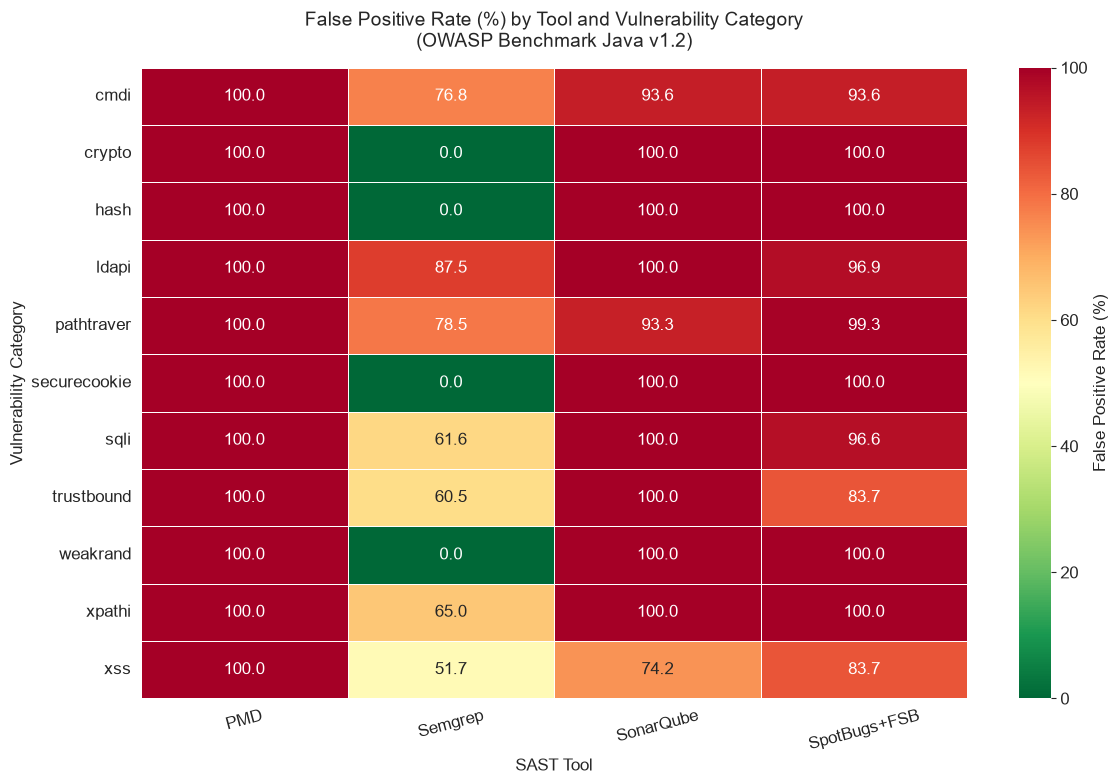

Heatmap saved


In [18]:
# heatmap - best way to visualise this per category breakdown
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(df_pivot, 
            annot=True, 
            fmt='.1f',
            cmap='RdYlGn_r',  # red = high FP, green = low FP
            vmin=0, vmax=100,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'False Positive Rate (%)'})

ax.set_title('False Positive Rate (%) by Tool and Vulnerability Category\n(OWASP Benchmark Java v1.2)', 
             fontsize=14, pad=15)
ax.set_xlabel('SAST Tool', fontsize=12)
ax.set_ylabel('Vulnerability Category', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(r'C:\SAST-Benchmark\results\chart_heatmap_fpr.png', dpi=150)
plt.show()
print("Heatmap saved")

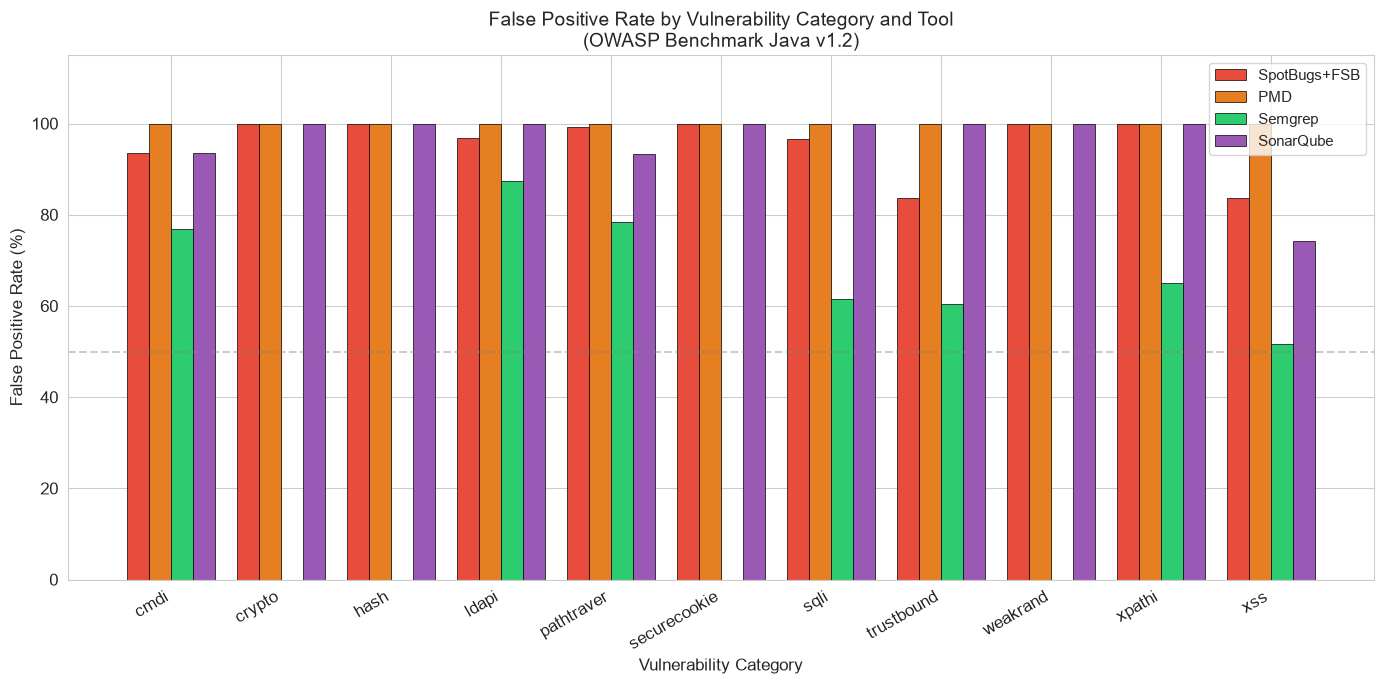

Chart saved


In [19]:
# grouped bar chart for per category FP rates
# easier to read than heatmap for presentations

fig, ax = plt.subplots(figsize=(14, 7))

cats = df_pivot.index.tolist()
x = range(len(cats))
width = 0.2

tools_list = ['SpotBugs+FSB', 'PMD', 'Semgrep', 'SonarQube']
colors_list = ['#e74c3c', '#e67e22', '#2ecc71', '#9b59b6']

for i, (tool, color) in enumerate(zip(tools_list, colors_list)):
    if tool in df_pivot.columns:
        vals = [df_pivot.loc[cat, tool] if cat in df_pivot.index else 0 for cat in cats]
        offset = (i - 1.5) * width
        ax.bar([xi + offset for xi in x], vals, width, 
               label=tool, color=color, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Vulnerability Category', fontsize=12)
ax.set_ylabel('False Positive Rate (%)', fontsize=12)
ax.set_title('False Positive Rate by Vulnerability Category and Tool\n(OWASP Benchmark Java v1.2)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=30, ha='right')
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(r'C:\SAST-Benchmark\results\chart_category_fpr.png', dpi=150)
plt.show()
print("Chart saved")

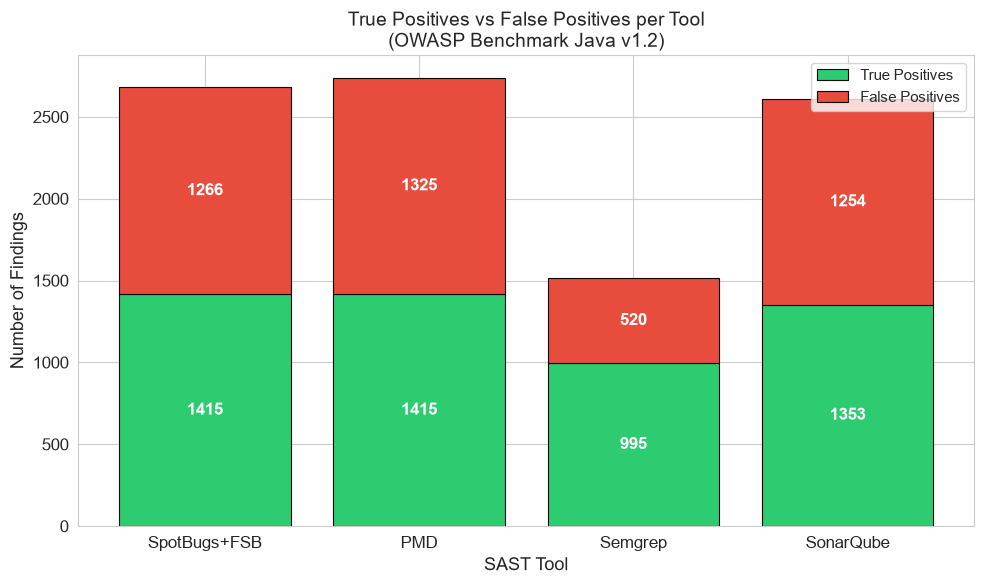

Chart saved


In [20]:
# stacked bar chart showing TP vs FP counts for each tool
# helps visualise the scale of false positives vs true positives

fig, ax = plt.subplots(figsize=(10, 6))

tools_list = df_results['tool'].tolist()
tp_vals = df_results['TP'].tolist()
fp_vals = df_results['FP'].tolist()

bars1 = ax.bar(tools_list, tp_vals, label='True Positives', 
               color='#2ecc71', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(tools_list, fp_vals, bottom=tp_vals, label='False Positives', 
               color='#e74c3c', edgecolor='black', linewidth=0.8)

# add labels inside bars
for bar, val in zip(bars1, tp_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val/2,
            str(val), ha='center', va='center', fontweight='bold', color='white')

for bar, tp, fp in zip(bars2, tp_vals, fp_vals):
    ax.text(bar.get_x() + bar.get_width()/2, tp + fp/2,
            str(fp), ha='center', va='center', fontweight='bold', color='white')

ax.set_xlabel('SAST Tool', fontsize=13)
ax.set_ylabel('Number of Findings', fontsize=13)
ax.set_title('True Positives vs False Positives per Tool\n(OWASP Benchmark Java v1.2)', fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(r'C:\SAST-Benchmark\results\chart_tp_fp_stacked.png', dpi=150)
plt.show()
print("Chart saved")

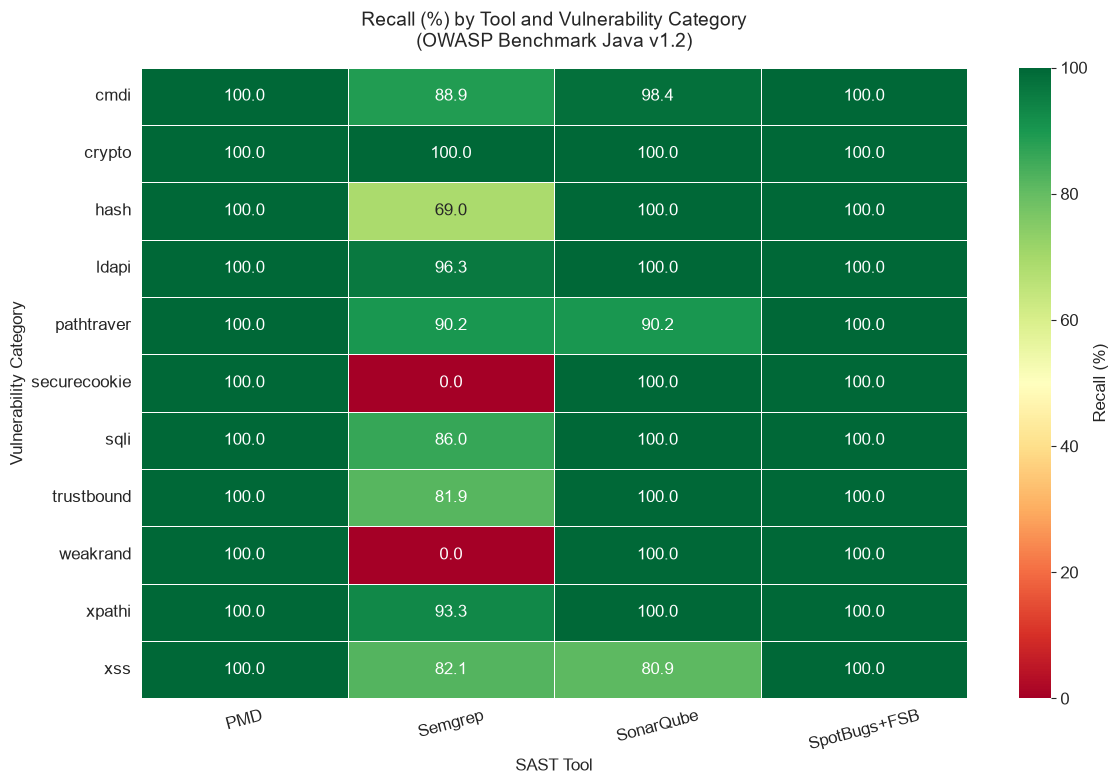

Heatmap saved


In [21]:
# recall by category - shows which tool catches more real vulnerabilities per category

def recall_by_category(findings, expected, tool_name):
    flagged = set(f['test_name'] for f in findings)
    
    cat_stats = {}
    for test_name, info in expected.items():
        cat = info['category']
        if cat not in cat_stats:
            cat_stats[cat] = {'tp': 0, 'fn': 0}
        
        is_vuln = info['real_vulnerability']
        was_flagged = test_name in flagged
        
        if is_vuln and was_flagged:
            cat_stats[cat]['tp'] += 1
        elif is_vuln and not was_flagged:
            cat_stats[cat]['fn'] += 1
    
    rows = []
    for cat, s in cat_stats.items():
        recall = s['tp'] / (s['tp'] + s['fn']) if (s['tp'] + s['fn']) > 0 else 0
        rows.append({'category': cat, 'tool': tool_name, 'recall': round(recall * 100, 1)})
    return rows

recall_rows = []
recall_rows.extend(recall_by_category(spotbugs_findings, expected, 'SpotBugs+FSB'))
recall_rows.extend(recall_by_category(pmd_findings, expected, 'PMD'))
recall_rows.extend(recall_by_category(semgrep_findings, expected, 'Semgrep'))
recall_rows.extend(recall_by_category(sonar_findings, expected, 'SonarQube'))

df_recall = pd.DataFrame(recall_rows)
df_recall_pivot = df_recall.pivot(index='category', columns='tool', values='recall')

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(df_recall_pivot,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',  # green = high recall, red = low recall
            vmin=0, vmax=100,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Recall (%)'})

ax.set_title('Recall (%) by Tool and Vulnerability Category\n(OWASP Benchmark Java v1.2)',
             fontsize=14, pad=15)
ax.set_xlabel('SAST Tool', fontsize=12)
ax.set_ylabel('Vulnerability Category', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(r'C:\SAST-Benchmark\results\chart_heatmap_recall.png', dpi=150)
plt.show()
print("Heatmap saved")

In [22]:
# save all results to csv files so we have them for the report

# overall metrics
df_results.to_csv(r'C:\SAST-Benchmark\results\metrics_overall.csv', index=False)

# per category FP rates
df_pivot.to_csv(r'C:\SAST-Benchmark\results\metrics_fpr_by_category.csv')

# per category recall
df_recall_pivot.to_csv(r'C:\SAST-Benchmark\results\metrics_recall_by_category.csv')

print("All results exported to CSV files")
print("\nOverall metrics summary:")
print(df_results[['tool', 'TP', 'FP', 'FN', 'TN', 'Precision', 'Recall', 'F1', 'FP_Rate']].to_string(index=False))

All results exported to CSV files

Overall metrics summary:
        tool   TP   FP  FN  TN  Precision  Recall    F1  FP_Rate
SpotBugs+FSB 1415 1266   0  59      0.528   1.000 0.691    0.955
         PMD 1415 1325   0   0      0.516   1.000 0.681    1.000
     Semgrep  995  520 420 805      0.657   0.703 0.679    0.392
   SonarQube 1353 1254  62  71      0.519   0.956 0.673    0.946
